***Wytrenowanie oraz parametryzacja modelu uczenia maszynowego do klasyfikacji udaru mozgu na podstawie datasetu stroke_data.csv***

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score
from xgboost import XGBClassifier


In [3]:
stroke_data = pd.read_csv('stroke_data.csv')

stroke_data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Sprawdzenie graficzne targetu analizy - tabeli stroke.

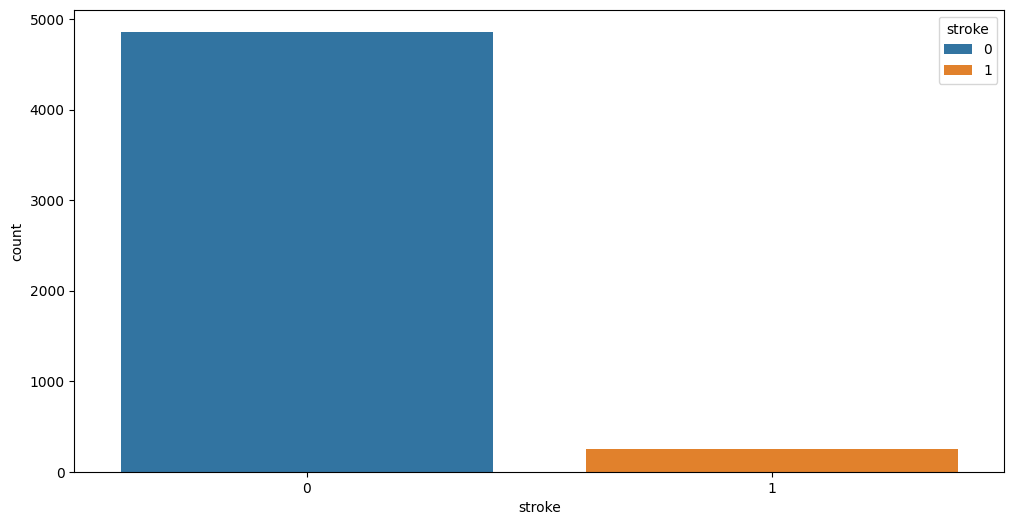

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=stroke_data, x='stroke', hue='stroke')
plt.show()

Widac jest ze zbior danych zawiera w glownej mierze informacje o osobach ktore udaru nie dostaly. <br>

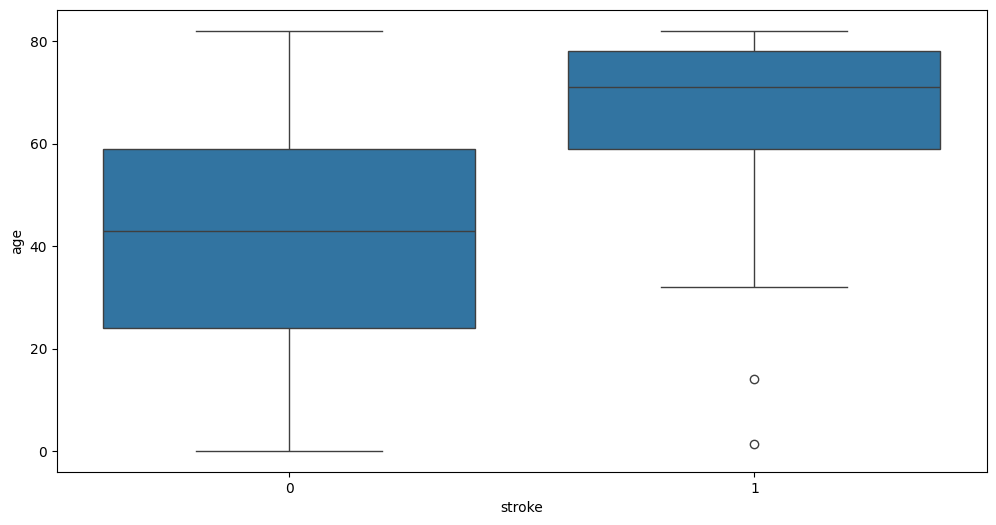

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=stroke_data, y='age', x='stroke')
plt.show()

Boxplot idealnie obrazuje jak wyglada sytuacja z porownaniem wieku do wystapienia/niewystapienia udaru. <br>
To jest dosc oczywiste ze osoby starsze sa bardziej narazone. <br>
Dzieje sie to chociazby ze wzgledu na starzenie sie organizmu oraz czeste wystepowanie chorob wspolistniejacych.

Aby lepiej zrozumiec dataset nalezy sprawdzic jak maja sie inne dane. <br>
Najlepiej bedzie to wyrazic graficznie.

In [26]:
box = []
hist = []
count = []

for col, type in zip(stroke_data.columns, stroke_data.dtypes):
    if type == 'float64':
        box.append(col)
    elif type == 'int64':
        count.append(col)
    else:
        hist.append(col)

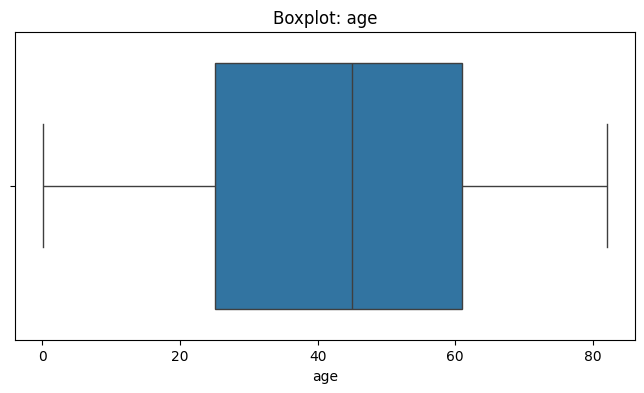

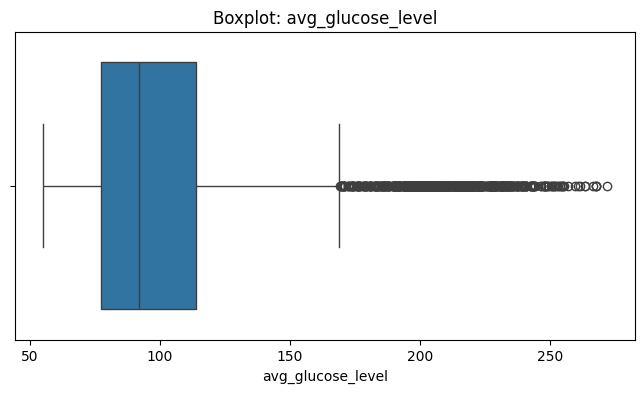

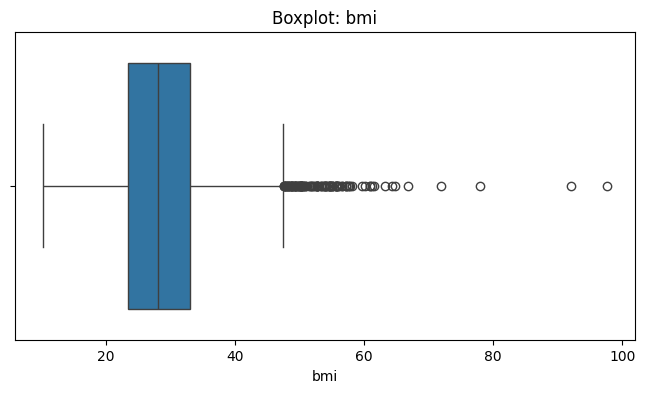

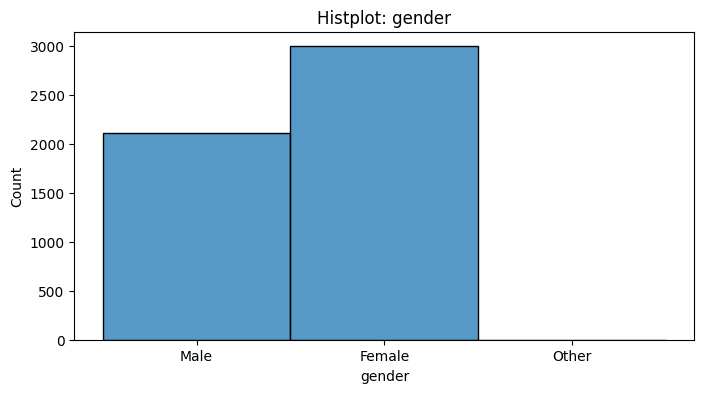

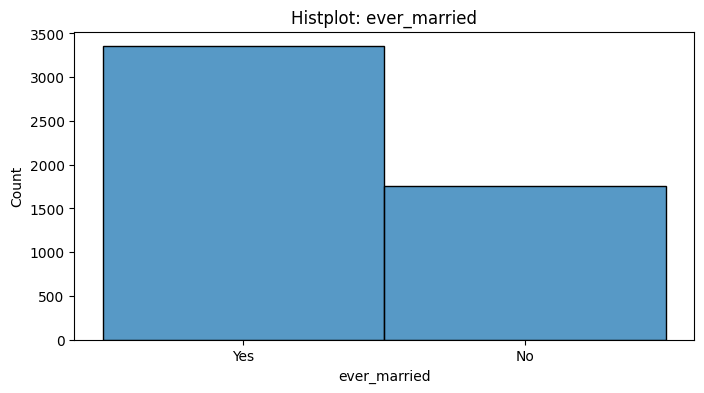

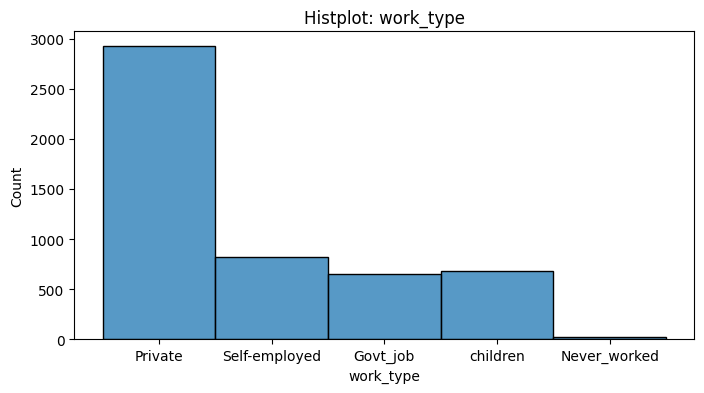

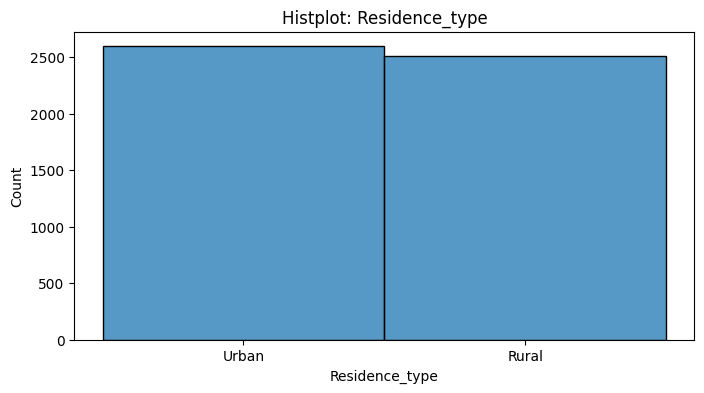

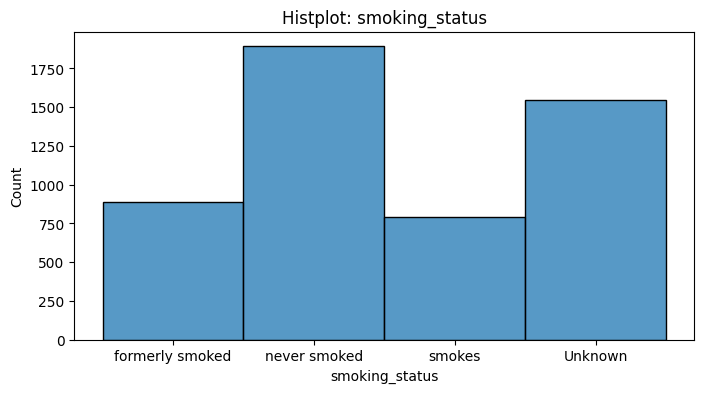

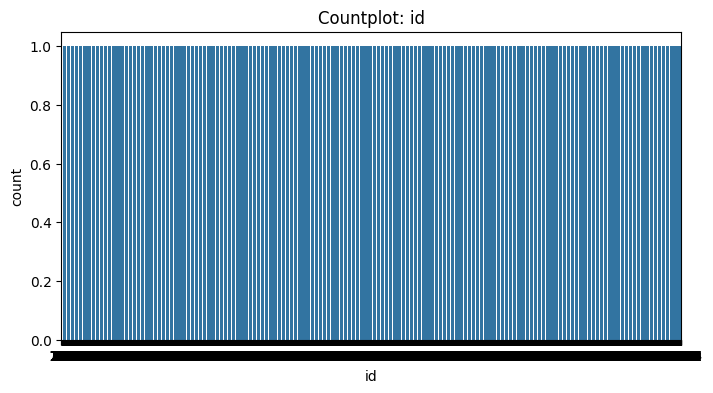

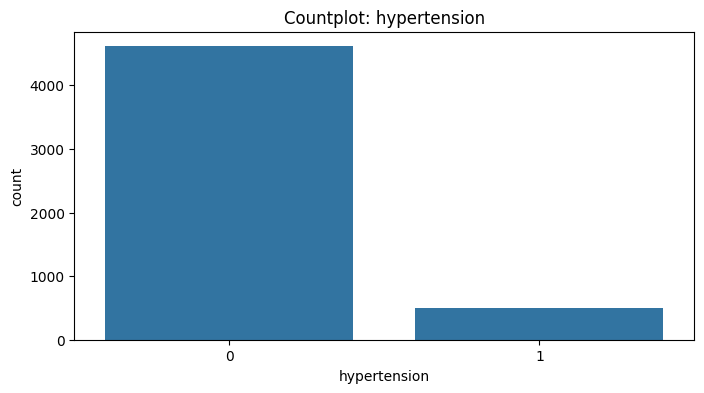

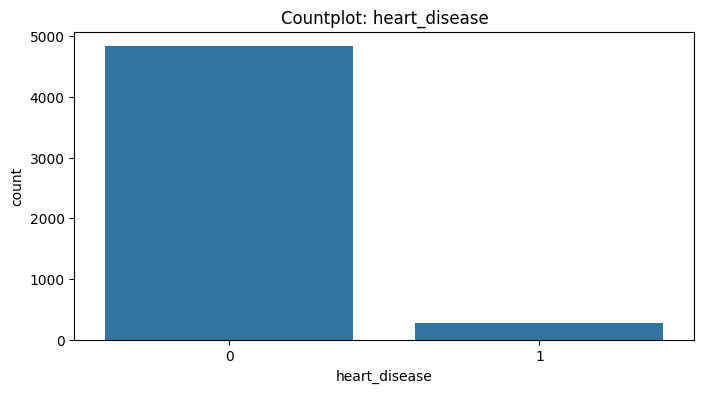

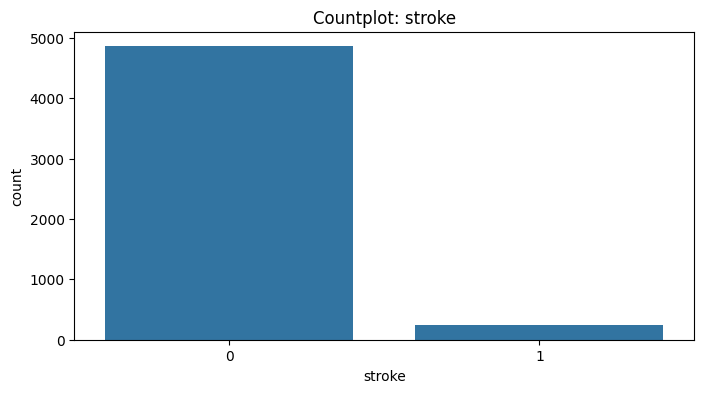

In [30]:
plots = {
    'to_box': box,
    'to_hist': hist,
    'to_count': count
}

for direct, params in plots.items():
    if direct == "to_box":
        for col in params:
            plt.figure(figsize=(8,4))
            plt.title(f"Boxplot: {col}")
            sns.boxplot(x=stroke_data[col])
            plt.show()
    elif direct == "to_count":
        for col in params:
            plt.figure(figsize=(8,4))
            plt.title(f"Countplot: {col}")
            sns.countplot(x=stroke_data[col])
            plt.show()
    else:
        for col in params:
            plt.figure(figsize=(8,4))
            plt.title(f"Histplot: {col}")
            sns.histplot(x=stroke_data[col])
            plt.show()

In [39]:
backup = pd.get_dummies(data=stroke_data)
corr = backup.corr()

backup.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


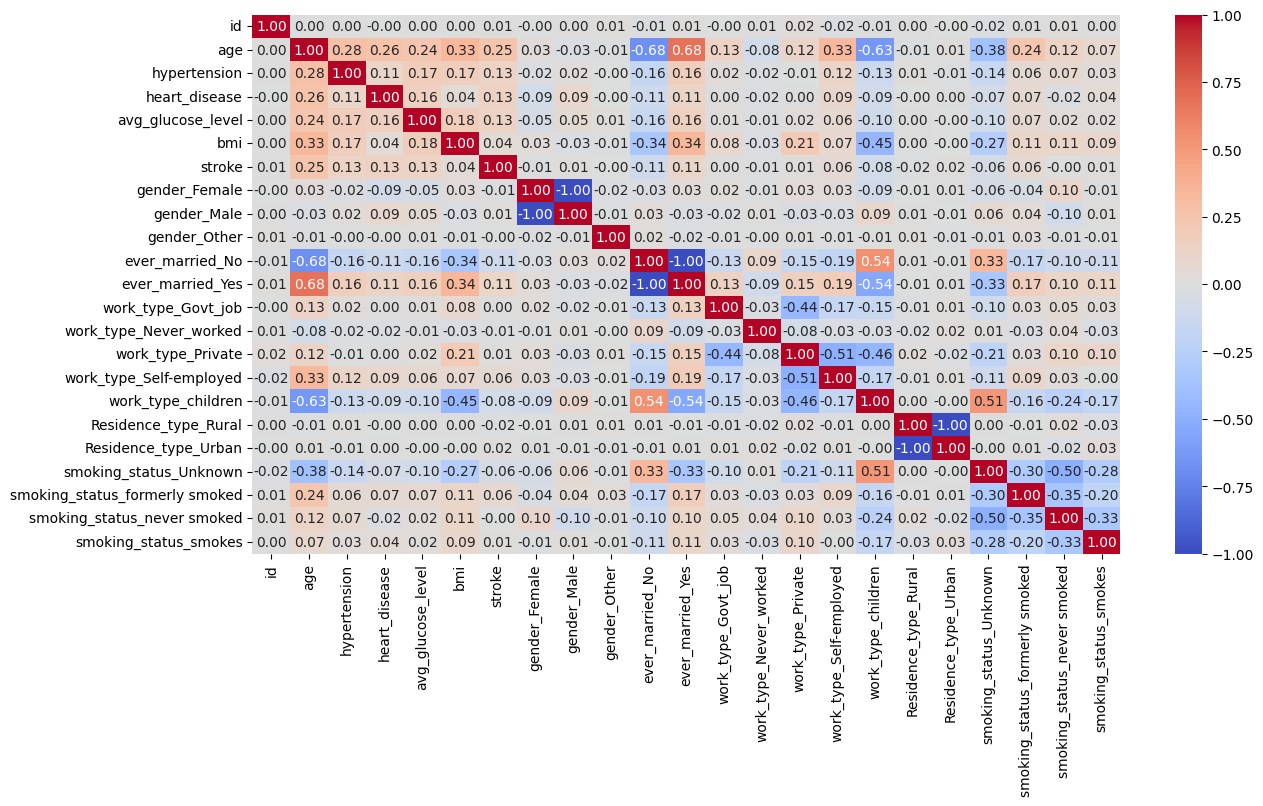

In [40]:
plt.figure(figsize=(14, 7))
sns.heatmap(data=corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

Po spojrzeniu na posiadane dane pora przejsc do budowania pipelinow i parametryzacji modeli.

In [42]:
text_cols = stroke_data.select_dtypes(include=['object']).columns

for col in text_cols:
    print(col)
    print(stroke_data[col].unique())

gender
['Male' 'Female' 'Other']
ever_married
['Yes' 'No']
work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type
['Urban' 'Rural']
smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


Pora wybrac kolumny ktore zostana przekazane modelowi.

In [60]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'heart_disease', 'hypertension']
onehot_cols = ['ever_married', 'work_type']
ordinal_cols = ['smoking_status']

preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'), onehot_cols),
    ('ordl', OrdinalEncoder(categories=[['Unknown', 'never smoked', 'formerly smoked', 'smokes']]), [ordinal_cols[0]])
])

preprocessor_scaled

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [61]:
y = stroke_data['stroke']
X = stroke_data[['age', 'avg_glucose_level', 'bmi', 'heart_disease', 'hypertension', 'smoking_status', 'ever_married', 'work_type']]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Wybor modeli: dwa drzewiaste (XGB, Forest), jeden "prosty" (Logistic) oraz DummyClassifier jako absolutny basemodel.

In [63]:
pipelines = {
    'Dummy': Pipeline([('preprocessor', preprocessor_scaled), ('model', DummyClassifier(random_state=42))]),
    'Logistic': Pipeline([('preprocessor', preprocessor_scaled), ('model', LogisticRegression(random_state=42))]),
    'Forest': Pipeline([('preprocessor', preprocessor_scaled), ('model', RandomForestClassifier(random_state=42))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor_scaled), ('model', XGBClassifier(random_state=42))])
}

Uzycie cross_validate zamiast cross_val_score aby przekazac do scoring wiecej niz 1 parametr

In [76]:
for name, pipeline in pipelines.items():
    scores = cross_validate(estimator=pipeline, X=X_train, y=y_train, cv=5, scoring=['recall', 'precision', 'f1'])
    print("-" * 30)
    print(f"Wyniki dla {name}:")
    print(f"Recall: {scores['test_recall'].mean():.3f} +- {scores['test_recall'].std():.3f}")
    print(f"Precision: {scores['test_precision'].mean():.3f} +- {scores['test_precision'].std():.3f}")
    print(f"F1: {scores['test_f1'].mean():.3f} +- {scores['test_f1'].std():.3f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

------------------------------
Wyniki dla Dummy:
Recall: 0.000 +- 0.000
Precision: 0.000 +- 0.000
F1: 0.000 +- 0.000
------------------------------
Wyniki dla Logistic:
Recall: 0.000 +- 0.000
Precision: 0.000 +- 0.000
F1: 0.000 +- 0.000
------------------------------
Wyniki dla Forest:
Recall: 0.015 +- 0.012
Precision: 0.157 +- 0.135
F1: 0.027 +- 0.022
------------------------------
Wyniki dla XGBoost:
Recall: 0.060 +- 0.037
Precision: 0.185 +- 0.100
F1: 0.090 +- 0.053


Wyniki modelu pokazuja cos co mozna bylo wywnioskowac juz po spojrzeniu na target analizy czyli kolumne stroke. <br>
Jesli duza ilosc danych mowi o pacjentach ktorzy tego udaru nie mieli (spojrzec na countplot: stroke).<br>
Tu wiec pojawia sie problem z obliczeniem metryk dla Regresji Logistycznej, gdzie model majac tak niewiele przypadkow udaru klasyfikuje wszystkie osoby na podstawie biezacego progu (treshold = 0.5) jako osobe zdrowa.

Mozna starac sie temu zaradzic poprzez ustawienie parametru class_weight = 'balanced' (oraz scale_pos_weight dla XGBoosta).

In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

pipelines = {
    'Dummy': Pipeline([('preprocessor', preprocessor_scaled), ('model', DummyClassifier(random_state=42))]),
    'Logistic': Pipeline([('preprocessor', preprocessor_scaled), ('model', LogisticRegression(random_state=42, class_weight='balanced'))]),
    'Forest': Pipeline([('preprocessor', preprocessor_scaled), ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocessor', preprocessor_scaled), ('model', XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight))])
}

In [78]:
for name, pipeline in pipelines.items():
    scores = cross_validate(estimator=pipeline, X=X_train, y=y_train, cv=5, scoring=['recall', 'precision', 'f1'])
    print("-" * 30)
    print(f"Wyniki dla {name}:")
    print(f"Recall: {scores['test_recall'].mean():.3f} +- {scores['test_recall'].std():.3f}")
    print(f"Precision: {scores['test_precision'].mean():.3f} +- {scores['test_precision'].std():.3f}")
    print(f"F1: {scores['test_f1'].mean():.3f} +- {scores['test_f1'].std():.3f}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

------------------------------
Wyniki dla Dummy:
Recall: 0.000 +- 0.000
Precision: 0.000 +- 0.000
F1: 0.000 +- 0.000
------------------------------
Wyniki dla Logistic:
Recall: 0.779 +- 0.061
Precision: 0.128 +- 0.011
F1: 0.220 +- 0.017
------------------------------
Wyniki dla Forest:
Recall: 0.015 +- 0.012
Precision: 0.217 +- 0.194
F1: 0.028 +- 0.023
------------------------------
Wyniki dla XGBoost:
Recall: 0.181 +- 0.065
Precision: 0.192 +- 0.061
F1: 0.185 +- 0.062


Wyniki dla Regresji Logistycznej bardzo sie poprawily i wyszly takie jakie mozna sie bylo spodziewac. <br>
Regresja dla tak usystematyzowanych danych wypadla najlepiej. Nalezy jeszcze sprawdzic czy wyniki zmienia sie na korzysc modeli drzewiastych przy doborze parametrow w GrudSearchCV.

In [80]:
logistic_params = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

grid_logistic = GridSearchCV(
    estimator=pipelines['Logistic'],
    param_grid=logistic_params,
    scoring='recall',
    cv=5,
    verbose=1
)

grid_logistic.fit(X_train, y_train)
grid_logistic_best = grid_logistic.best_estimator_
print(f"Najlepsze parametry dla {grid_logistic.__class__.__name__}: {grid_logistic.best_params_}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Najlepsze parametry dla GridSearchCV: {'model__C': 0.01}


In [82]:
forest_params = {
    "model__max_depth": [2, 3, 4, 5],
    "model__n_estimators": [50, 100, 200, 300],
    "model__min_samples_leaf": [2, 5, 10]
}

grid_forest = GridSearchCV(
    estimator=pipelines['Forest'],
    param_grid=forest_params,
    scoring='recall',
    cv=5,
    verbose=1
)

grid_forest.fit(X_train, y_train)
grid_forest_best = grid_forest.best_estimator_
print(f"Najlepsze parametry dla {grid_forest.__class__.__name__}: {grid_forest.best_params_}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Najlepsze parametry dla GridSearchCV: {'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__n_estimators': 50}


In [83]:
xgb_params = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__n_estimators": [50, 100, 200, 300],
    "model__max_depth": [2, 3, 4, 5],
    "model__gamma": [0, 1]
}

grid_xgb = GridSearchCV(
    estimator=pipelines['XGBoost'],
    param_grid=xgb_params,
    scoring='recall',
    cv=5,
    verbose=1
)

grid_xgb.fit(X_train, y_train)
grid_xgb_best = grid_xgb.best_estimator_
print(f"Najlepsze parametry dla {grid_xgb.__class__.__name__}: {grid_xgb.best_params_}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Najlepsze parametry dla GridSearchCV: {'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 50}


Pora na test na zablokowanych parametrach.

In [84]:
models = {
    'Logistic': grid_logistic_best,
    'Forest': grid_forest_best,
    'XGBoost': grid_xgb_best
}

for name, model in models.items():
    scores = cross_validate(estimator=model, X=X_train, y=y_train, cv=5, scoring=['recall', 'precision', 'f1'])
    print("-" * 30)
    print(f"Wyniki dla {name}:")
    print(f"Recall: {scores['test_recall'].mean():.3f} +- {scores['test_recall'].std():.3f}")
    print(f"Precision: {scores['test_precision'].mean():.3f} +- {scores['test_precision'].std():.3f}")
    print(f"F1: {scores['test_f1'].mean():.3f} +- {scores['test_f1'].std():.3f}")

------------------------------
Wyniki dla Logistic:
Recall: 0.809 +- 0.033
Precision: 0.128 +- 0.011
F1: 0.222 +- 0.017
------------------------------
Wyniki dla Forest:
Recall: 0.845 +- 0.048
Precision: 0.122 +- 0.010
F1: 0.213 +- 0.016
------------------------------
Wyniki dla XGBoost:
Recall: 0.839 +- 0.025
Precision: 0.120 +- 0.009
F1: 0.209 +- 0.013


 
Zastosowanie class_weight='balanced' drastycznie poprawilo recall (z ~0.0 do ~0.8), <br> 
kosztem niskiej precyzji (~0.12-0.13) — model generuje duzo falszywych alarmow. <br>
W kontekscie medycznym (wykrywanie ryzyka udaru) jest to akceptowalny kompromis: <br>
koszt przeoczenia realnego przypadku jest wyzszy niz koszt dodatkowej, niepotrzebnej<br> 
konsultacji lekarskiej.

Jako model wybieram Logistic Regression ze wzgledu na swoja prosta budowe oraz najlepsza "wyjasnialnosc".

In [107]:
chosen_model = models['Logistic']
y_pred = chosen_model.predict(X_test)
recall = recall_score(y_pred=y_pred, y_true=y_test)
precision = precision_score(y_pred=y_pred, y_true=y_test)
f1 = f1_score(y_pred=y_pred, y_true=y_test)
print(f"Wynik metryki recall dla LogisticRegression: {recall:.2f}")
print(f"Wynik metryki precision dla LogisticRegression: {precision:.2f}")
print(f"Wynik metryki f1 dla LogisticRegression: {f1:.2f}")

Wynik metryki recall dla LogisticRegression: 0.84
Wynik metryki precision dla LogisticRegression: 0.15
Wynik metryki f1 dla LogisticRegression: 0.25


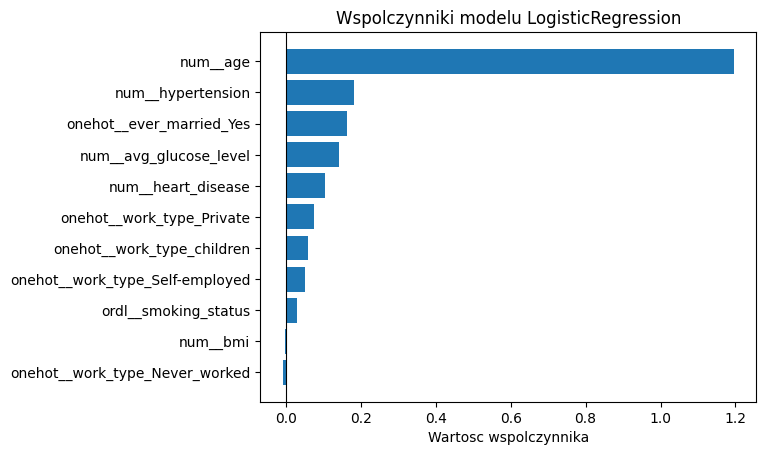

In [99]:
feature_names = chosen_model.named_steps['preprocessor'].get_feature_names_out()
coefs = chosen_model.named_steps['model'].coef_[0]

importances = pd.DataFrame({
    'features_names': feature_names,
    'importances': coefs
}).sort_values(by='importances')

plt.barh(y=importances['features_names'], width=importances['importances'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Wspolczynniki modelu LogisticRegression")
plt.xlabel("Wartosc wspolczynnika")
plt.show()

Wykres idealnie pokazuje jak poszczegole zmienne wplywaly na wynik ostatecznej klasyfikacji. <br>
Jak widac na obrazku powyzej, wiek jest najwazniejszym parametrem oraz co bardzo ciekawe zadna ze zmiennych nie wplywa wprost na spadek prawdopodobienstaw udaru. <br>
Jedynie work_type_never_worked znajduje sie delikatnie ponizej 0, jest to jednak zbyt mala wartosc przy tak duzej ilosci "dodatnych" parametrow zeby miec realny wplyw na klasyfikacje. <br>
BMI ma wartosc bliska zeru, co odnoszac sie do wiedzy medycznej moze wydawac sie falzsywe bo BMI rzeczywiscie wplywa na mozliwosc udaru, niescislosc ta wynika wprost ze specyfiki datasetu.

Macierz korelacji graficznie obrazujaca wynik wybranego modelu.

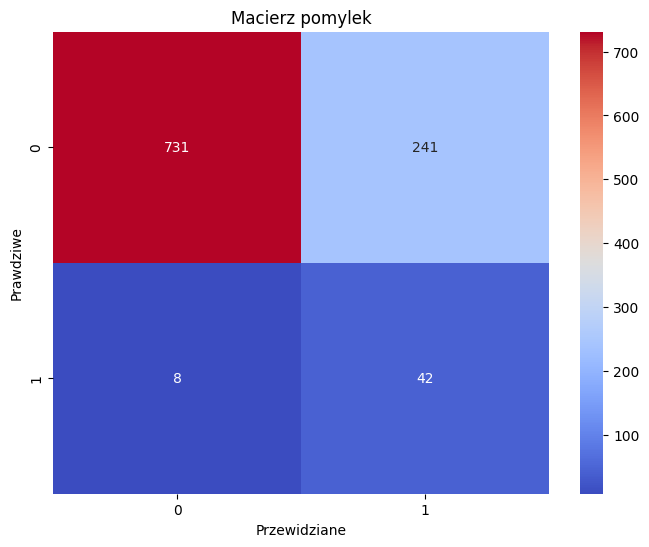

In [105]:
conf = confusion_matrix(y_pred=y_pred, y_true=y_test)
plt.figure(figsize=(8, 6))
plt.title('Macierz pomylek')
sns.heatmap(data=conf, cmap='coolwarm', annot=True, fmt='d')
plt.xlabel('Przewidziane')
plt.ylabel('Prawdziwe')
plt.show()

Na macierzy widac jest ze na pare tysiecy przypadkow tylko 8 zostalo zakwalifikowanych blednie (blednie z narazeniem zycia). <br>
Mozna wartosc ta zmiejszyc do 0 za pomoca manipulacji progu (treshold).